# Plot timeseries

In [1]:
import os, glob
import numpy as np
import pandas as pd
import xarray as xr
import matplotlib.pyplot as plt

# ----------------------
# USER SETTINGS
# ----------------------
domain_id = 'Bangkok'
station_id = "THM00048420"
dataset    = "GHCNh"         # used to form the obs filename
year       = 2025
setting = "test"

data_dir = "../../sample_data/"
wrf_glob   =  os.path.join(data_dir, f"Run_WRF/{domain_id}/{setting}/wrfout_d03_*")  # pattern for wrfout files in the working dir
obs_dir = os.path.join(data_dir, f"point_data/{dataset}/{year}/")
stations_csv = os.path.join(data_dir, f"point_data/{dataset}/summaries/stations_summary.csv")
extract_wrf_dir = os.path.join(data_dir, f"/WRF/{year}/")

# Which WRF variables to pull + how to map them to obs column names
# (left = column name in the obs CSV, right = WRF var in wrfout)
variable_map = {
    "temperature": "T2",               # 2m temperature [K] (convert to °C if needed)
    "dew_point_temperature": "calc",   # computed from T2 and Q2
    "station_level_pressure": "PSFC",  # surface pressure [Pa]
    "wind_direction": "calc",          # computed from U10 and V10
    "wind_speed": "calc",              # computed from U10 and V10
    "wind_gust": "WSPD10MAX",          # maximum wind speed (if available in output)
    "precipitation": "RAINC+RAINNC",   # accumulated precipitation [mm]
    "relative_humidity": "calc",        # 2m relative humidity [%]
    "wet_bulb_temperature": "calc",    # computed from T2, Q2, PSFC
    "snow_depth": "SNOWH"              # snow height [m]
}


# Preload all required variables (avoid repeated ds[...] access)
needed_vars = ["T2", "Q2", "PSFC", "U10", "V10",
               "RAINC", "RAINNC", "SLP", "SNOWH", "WSPD10MAX"]

start_date = '2025-01-01 00:00:00'
end_date = '2025-01-07 23:00:00'

In [2]:
# ----------------------
# 1) Read station lat/lon
# ----------------------
def read_station_info(stations_csv, station_id):
    """Read station lat/lon from summary CSV."""
    st = pd.read_csv(stations_csv)

    lat_col = next(c for c in st.columns if c.lower() in ("lat","latitude"))
    lon_col = next(c for c in st.columns if c.lower() in ("lon","longitude","lng"))
    id_col  = next(c for c in st.columns if c.lower() in ("station_id","id","station","ghcn_id"))

    row = st.loc[st[id_col].astype(str) == str(station_id)]
    if row.empty:
        raise ValueError(f"station_id={station_id} not found in {stations_csv}")

    lat0 = float(row.iloc[0][lat_col])
    lon0 = float(row.iloc[0][lon_col])
    return lat0, lon0

lat0, lon0 = read_station_info(stations_csv, station_id)
lat0, lon0

(13.52, 100.75)

In [3]:
# ----------------------
# 2) Open WRF output(s)
# ----------------------
def open_wrf_outputs(wrf_glob):
    """Open multiple WRF output files as one dataset."""
    wrf_files = sorted(glob.glob(wrf_glob))
    if not wrf_files:
        raise FileNotFoundError(f"No files matched pattern: {wrf_glob}")
    
    ds = xr.open_mfdataset(
        wrf_files, combine="nested", decode_times=True, concat_dim="Time"
    )
    return ds

ds = open_wrf_outputs(wrf_glob)
ds

<xarray.Dataset> Size: 8GB
Dimensions:                (Time: 169, south_north: 99, west_east: 99,
                            bottom_top: 47, bottom_top_stag: 48,
                            soil_layers_stag: 4, west_east_stag: 100,
                            south_north_stag: 100, seed_dim_stag: 2)
Coordinates:
    XLAT                   (Time, south_north, west_east) float32 7MB dask.array<chunksize=(1, 50, 50), meta=np.ndarray>
    XLONG                  (Time, south_north, west_east) float32 7MB dask.array<chunksize=(1, 50, 50), meta=np.ndarray>
    XTIME                  (Time) datetime64[ns] 1kB dask.array<chunksize=(24,), meta=np.ndarray>
    XLAT_U                 (Time, south_north, west_east_stag) float32 7MB dask.array<chunksize=(1, 50, 50), meta=np.ndarray>
    XLONG_U                (Time, south_north, west_east_stag) float32 7MB dask.array<chunksize=(1, 50, 50), meta=np.ndarray>
    XLAT_V                 (Time, south_north_stag, west_east) float32 7MB dask.array<chunksize=(1, 50, 50), meta=np.ndarray>
    XLONG_V                (Time, south_north_stag, west_east) float32 7MB dask.array<chunksize=(1, 50, 50), meta=np.ndarray>
Dimensions without coordinates: Time, south_north, west_east, bottom_top,
                                bottom_top_stag, soil_layers_stag,
                                west_east_stag, south_north_stag, seed_dim_stag
Data variables: (12/210)
    Times                  (Time) |S19 3kB dask.array<chunksize=(1,), meta=np.ndarray>
    LU_INDEX               (Time, south_north, west_east) float32 7MB dask.array<chunksize=(1, 50, 50), meta=np.ndarray>
    ZNU                    (Time, bottom_top) float32 32kB dask.array<chunksize=(1, 47), meta=np.ndarray>
    ZNW                    (Time, bottom_top_stag) float32 32kB dask.array<chunksize=(1, 48), meta=np.ndarray>
    ZS                     (Time, soil_layers_stag) float32 3kB dask.array<chunksize=(1, 4), meta=np.ndarray>
    DZS                    (Time, soil_layers_stag) float32 3kB dask.array<chunksize=(1, 4), meta=np.ndarray>
    ...                     ...
    PCB                    (Time, south_north, west_east) float32 7MB dask.array<chunksize=(1, 50, 50), meta=np.ndarray>
    PC                     (Time, south_north, west_east) float32 7MB dask.array<chunksize=(1, 50, 50), meta=np.ndarray>
    LANDMASK               (Time, south_north, west_east) float32 7MB dask.array<chunksize=(1, 50, 50), meta=np.ndarray>
    LAKEMASK               (Time, south_north, west_east) float32 7MB dask.array<chunksize=(1, 50, 50), meta=np.ndarray>
    SST                    (Time, south_north, west_east) float32 7MB dask.array<chunksize=(1, 50, 50), meta=np.ndarray>
    SST_INPUT              (Time, south_north, west_east) float32 7MB dask.array<chunksize=(1, 50, 50), meta=np.ndarray>
Attributes: (12/136)
    TITLE:                            OUTPUT FROM WRF V4.7.1 MODEL
    START_DATE:                      2025-01-01_00:00:00
    SIMULATION_START_DATE:           2025-01-01_00:00:00
    WEST-EAST_GRID_DIMENSION:        100
    SOUTH-NORTH_GRID_DIMENSION:      100
    BOTTOM-TOP_GRID_DIMENSION:       48
    ...                              ...
    ISLAKE:                          21
    ISICE:                           15
    ISURBAN:                         13
    ISOILWATER:                      14
    HYBRID_OPT:                      2
    ETAC:                            0.2

In [4]:
# ----------------------
# 3) Find nearest grid cell
# ----------------------

def find_nearest_grid(ds, lat0, lon0):
    """Find nearest grid cell indices (j,i) to a given lat/lon."""
    def _pick_2d(arr):
        return arr.isel(Time=0) if "Time" in arr.dims else arr

    XLAT  = _pick_2d(ds["XLAT"])
    XLONG = _pick_2d(ds["XLONG"])

    dist2 = (XLAT - lat0)**2 + (XLONG - lon0)**2
    j, i = np.unravel_index(np.argmin(dist2.values), dist2.shape)
    return j, i

j, i = find_nearest_grid(ds, lat0, lon0)

In [5]:
# ----------------------
# 4) Build WRF time index and extract time series
# ----------------------

def compute_rh2(T2, Q2, PSFC):
    """
    Compute 2m relative humidity (%) from WRF variables.
    T2   : 2m temperature [K]
    Q2   : 2m specific humidity [kg/kg]
    PSFC : surface pressure [Pa]
    """
    T = T2 - 273.15              # K → °C
    p = PSFC / 100.0             # Pa → hPa
    q = Q2                       # kg/kg

    # vapor pressure [hPa]
    e = q * p / (0.622 + 0.378 * q)

    # saturation vapor pressure [hPa] (Tetens formula)
    es = 6.112 * np.exp(17.67 * T / (T + 243.5))

    RH = 100.0 * e / es          # %
    RH = np.clip(RH, 0, 100)     # ensure bounds
    return RH

def compute_wet_bulb_temperature(T2, Q2, PSFC):
    """
    Wet bulb temperature [°C] using Stull (2011) approximation.
    Requires T2 [K], Q2 [kg/kg], PSFC [Pa].
    """
    T = T2 - 273.15                  # °C
    RH = compute_rh2(T2, Q2, PSFC)   # %

    Tw = (T * np.arctan(0.151977 * np.sqrt(RH + 8.313659)) +
          np.arctan(T + RH) -
          np.arctan(RH - 1.676331) +
          0.00391838 * RH**1.5 * np.arctan(0.023101 * RH) -
          4.686035)
    return Tw


# ----------------------
# Compute data dictionary
# ----------------------

def extract_wrf_timeseries(ds, j, i, variable_map, needed_vars):
    """
    Extract time series from WRF dataset at a given grid cell (j,i),
    mapped to observation variable names.

    Parameters
    ----------
    ds : xarray.Dataset
        Opened WRF dataset (combined with open_mfdataset).
    j, i : int
        Grid cell indices for the target station.
    variable_map : dict
        Mapping {obs_name: wrf_var or 'calc'}.
    needed_vars : list
        List of WRF variables to preload.
    compute_rh2 : function
        Function to compute relative humidity.
    compute_wet_bulb_temperature : function
        Function to compute wet bulb temperature.

    Returns
    -------
    wrf_df : pandas.DataFrame
        Time-indexed DataFrame of extracted variables.
    """

    # Build time index
    time_index = pd.to_datetime(ds['XTIME'].values)

    # Preload required variables to avoid repeated I/O
    wrf_data = {}
    for v in needed_vars:
        if v in ds.variables:
            wrf_data[v] = ds[v][:, j, i].values

    # Extract / compute variables
    data = {}
    for obs_name, wrf_var in variable_map.items():
        if wrf_var == "T2":
            data[obs_name] = wrf_data["T2"] - 273.15  # K → °C
        
        elif wrf_var == "PSFC":
            data[obs_name] = wrf_data["PSFC"] / 100.0  # Pa → hPa

        elif wrf_var == "RAINC+RAINNC":
            data[obs_name] = wrf_data["RAINC"] + wrf_data["RAINNC"]

        elif wrf_var == "calc":
            if obs_name == "dew_point_temperature":
                T = wrf_data["T2"] - 273.15
                q = wrf_data["Q2"]
                p = wrf_data["PSFC"] / 100.0
                e = q * p / (0.622 + 0.378 * q)
                data[obs_name] = 243.5 * np.log(e/6.112) / (17.67 - np.log(e/6.112))

            elif obs_name == "relative_humidity":
                data[obs_name] = compute_rh2(wrf_data["T2"], wrf_data["Q2"], wrf_data["PSFC"])

            elif obs_name == "wind_speed":
                u = wrf_data["U10"]
                v = wrf_data["V10"]
                data[obs_name] = np.sqrt(u**2 + v**2)

            elif obs_name == "wind_direction":
                u = wrf_data["U10"]
                v = wrf_data["V10"]
                data[obs_name] = (np.degrees(np.arctan2(-u, -v)) + 360) % 360

            elif obs_name == "wet_bulb_temperature":
                data[obs_name] = compute_wet_bulb_temperature(
                    wrf_data["T2"], wrf_data["Q2"], wrf_data["PSFC"]
                )

            else:
                continue

        elif wrf_var in wrf_data:
            data[obs_name] = wrf_data[wrf_var]

    # Build DataFrame
    wrf_df = pd.DataFrame(data, index=time_index)

    # Optional: handle precipitation as difference (rate instead of accumulation)
    if "precipitation" in wrf_df.columns:
        wrf_df["precipitation"] = wrf_df["precipitation"].diff().clip(lower=0)

    return wrf_df

wrf_df = extract_wrf_timeseries(ds, j, i, variable_map, needed_vars)
wrf_df

,temperature,dew_point_temperature,station_level_pressure,wind_direction,wind_speed,precipitation,relative_humidity,wet_bulb_temperature,snow_depth
2025-01-01 00:00:00,21.794159,17.751215,1012.752258,43.776855,3.326012,NaN,77.803421,18.967844,0.0
2025-01-01 01:00:00,23.533356,16.947578,1013.370239,49.777344,2.712663,0.0,66.535568,19.096378,0.0
2025-01-01 02:00:00,25.513275,16.592085,1012.320801,58.398834,3.246649,0.0,57.775692,19.632219,0.0
2025-01-01 03:00:00,27.185028,16.926456,1012.803772,68.406494,3.685868,0.0,53.465031,20.439064,0.0
2025-01-01 04:00:00,28.644562,17.095234,1011.820618,62.870850,3.820976,0.0,49.624268,21.067356,0.0
...,...,...,...,...,...,...,...,...,...
2025-01-07 20:00:00,21.099457,16.435837,1013.202026,64.837158,1.415620,0.0,74.695892,17.907936,0.0
2025-01-07 21:00:00,20.767578,16.295153,1013.366150,58.045227,0.949451,0.0,75.556656,17.703505,0.0
2025-01-07 22:00:00,20.314423,16.163168,1013.296326,65.440308,1.112960,0.0,77.048195,17.461267,0.0
2025-01-07 23:00:00,19.733093,15.968872,1013.259277,53.378204,1.541186,0.0,78.888947,17.135653,0.0


In [7]:
# ----------------------
# 4) Load observations and align
# ----------------------

def extract_observation_daya(obs_dir, dataset, station_id, year):
    obs_path = os.path.join(obs_dir, f"{dataset}_{station_id}_{year}.csv")
    if not os.path.exists(obs_path):
        raise FileNotFoundError(f"Observation file not found: {obs_path}")

    # Try to parse time; guess time column
    obs_df = pd.read_csv(obs_path, index_col=0)
    obs_df.index = pd.to_datetime(obs_df.index)

    # # Find a likely datetime column
    # time_col_candidates = [c for c in obs_df.columns if c.lower() in ("time","datetime","date","timestamp")]
    # if time_col_candidates:
    #     tcol = time_col_candidates[0]
    #     obs_df[tcol] = pd.to_datetime(obs_df[tcol])
    #     obs_df = obs_df.set_index(tcol)
    # else:
    #     # If no explicit time column, attempt to parse the index
    #     try:
    #         obs_df.index = pd.to_datetime(obs_df.index)
    #     except Exception:
    #         raise ValueError("Could not find/parse a datetime column in observations.")

    obs_df = obs_df[variable_map.keys()]
    obs_df[start_date:end_date]
    # Inner-join on timestamp
    return obs_df

obs_df = extract_observation_daya(obs_dir, dataset, station_id, year)
obs_df

,temperature,dew_point_temperature,station_level_pressure,wind_direction,wind_speed,wind_gust,precipitation,relative_humidity,wet_bulb_temperature,snow_depth
2025-01-01 00:00:00,22.0,18.5,1011.9,80.0,1.5,NaN,NaN,81.0,19.8,NaN
2025-01-01 01:00:00,24.7,12.4,NaN,80.0,3.6,NaN,NaN,46.0,NaN,NaN
2025-01-01 02:00:00,26.7,11.7,NaN,80.0,4.6,NaN,NaN,39.0,NaN,NaN
2025-01-01 03:00:00,27.5,19.0,1012.9,60.0,4.1,NaN,NaN,60.0,21.9,NaN
2025-01-01 04:00:00,29.6,11.9,NaN,40.0,4.1,NaN,NaN,34.0,NaN,NaN
...,...,...,...,...,...,...,...,...,...,...
2025-12-31 19:00:00,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
2025-12-31 20:00:00,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
2025-12-31 21:00:00,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
2025-12-31 22:00:00,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN


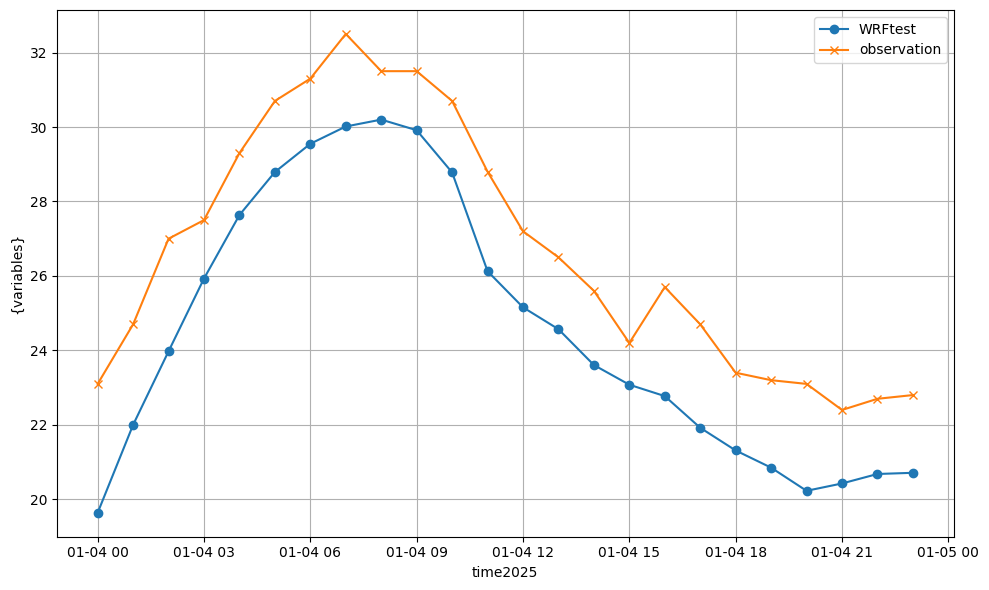

In [8]:
# ----------------------
# 5) Quick comparison stats (bias/RMSE) for mapped variables that exist on both sides
# ----------------------

odir = 'fig/'
def time_variation_graph(station, variables, start_date, end_date):

    # sim, obs = data_formatting(station, start_date, end_date)
    y_sim = wrf_df[start_date:end_date][variables]
    y_obs = obs_df[start_date:end_date][variables]
    x = y_obs.index

    # グラフを描画
    plt.figure(figsize=(10, 6))
    plt.plot(x, y_sim, label=f'WRF{setting}', marker='o')
    plt.plot(x, y_obs, label='observation', marker='x')
    
    # グラフの体裁を整える
    plt.xlabel(f'time{year}')
    plt.ylabel('{variables}')
    #plt.title('時刻ごとの気温変化')
    plt.legend()
    plt.grid(True)
    plt.tight_layout()

    # plt.savefig(odir + 'time_variation_graph.png') 
    plt.show()

time_variation_graph(station_id, "temperature", start_date='2025-01-04 00:00:00', end_date='2025-01-04 23:00:00')

In [9]:
# ----------------------
# 6) Quick comparison stats (bias/RMSE) for mapped variables that exist on both sides
# ----------------------
def stats_pair(wrf_series, obs_series):
    # Ensure data types are float for calculations
    a, b = wrf_series.align(obs_series, join='inner')
    a = a.astype(float)
    b = b.astype(float)

    # Find common non-missing data points
    common = a.notna() & b.notna()

    # If no common data points, return NaN series
    if not common.any():
        return pd.Series({"n": 0, "bias": np.nan, "rmse": np.nan, "corr": np.nan})

    # Calculate difference
    diff = a[common] - b[common]

    # Return statistics (n, bias, RMSE, correlation)
    return pd.Series({
        "n": common.sum(),
        "bias": diff.mean(),
        "rmse": np.sqrt((diff**2).mean()),
        "corr": a[common].corr(b[common])
    })

# Initialize list to hold stat results
rows = []
# Iterate over variable mapping (assuming obs_col is the key and wrf_col is the value, or vice-versa)
# Given the prompt, we assume variable_map has keys that exist in both obs_df and wrf_df
# Let's assume variable_map.keys() gives the common column names.
for var_name in variable_map.keys():
    # Check if the variable exists in both DataFrames
    if var_name in wrf_df.columns and var_name in obs_df.columns:
        # Pass the series directly to the stats function
        stats = stats_pair(wrf_df[var_name], obs_df[var_name]).rename(var_name)
        rows.append(stats)

# Create the final comparison table
comparison_stats = pd.DataFrame(rows)
comparison_stats

,n,bias,rmse,corr
temperature,168.0,-2.320495,2.618355,0.945826
dew_point_temperature,159.0,1.644755,3.883104,0.364256
station_level_pressure,58.0,1.223941,1.648882,0.766677
wind_direction,168.0,-66.317234,251.709614,-0.001105
wind_speed,168.0,0.288232,1.208654,0.598762
precipitation,0.0,NaN,NaN,NaN
relative_humidity,159.0,11.185518,18.013524,0.584691
wet_bulb_temperature,49.0,-2.346954,2.546541,0.890385
snow_depth,0.0,NaN,NaN,NaN
